In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

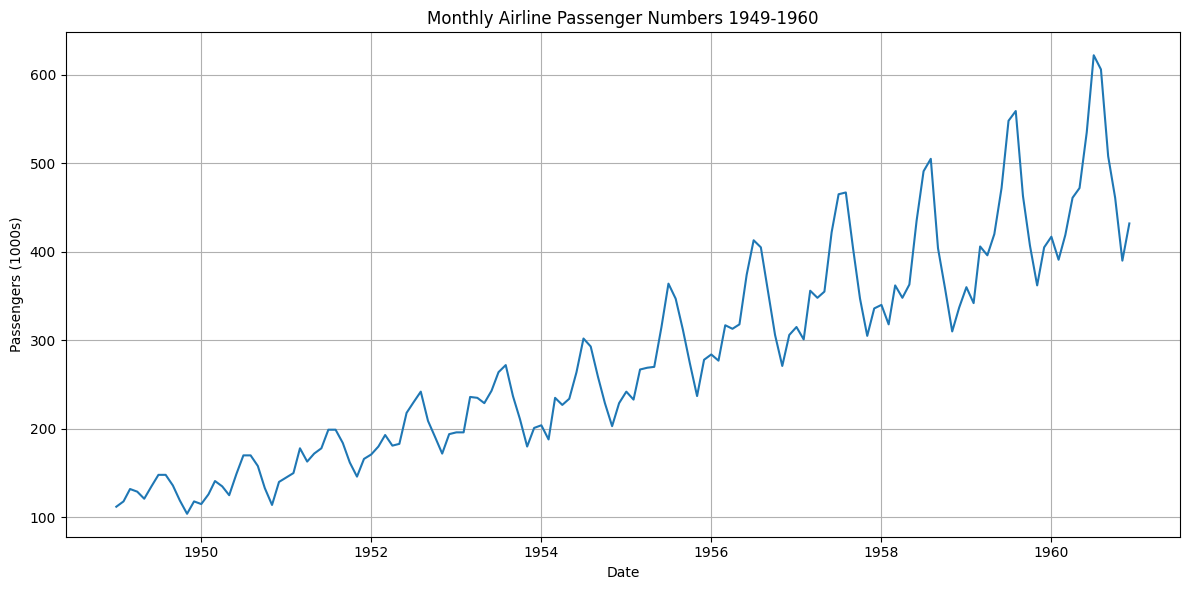

In [2]:
# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Download and prepare the Air Passengers dataset
# This is a classic time series dataset showing monthly airline passenger numbers
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url)
df.columns = ['Month', 'Passengers']
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)

# Plot the dataset
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Passengers'])
plt.title('Monthly Airline Passenger Numbers 1949-1960')
plt.xlabel('Date')
plt.ylabel('Passengers (1000s)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [3]:
print(f"Dataset shape: {df.shape}")
print(f"Date range: {df.index.min()} to {df.index.max()}")

Dataset shape: (144, 1)
Date range: 1949-01-01 00:00:00 to 1960-12-01 00:00:00


In [4]:
# Scale the data
scaler = MinMaxScaler(feature_range=(-1, 1))
df_scaled = scaler.fit_transform(df)

# Create sequences
def create_sequences(data, seq_length):
    xs = []
    ys = []
    
    for i in range(len(data) - seq_length):
        x = data[i:i+seq_length]
        y = data[i+seq_length]
        xs.append(x)
        ys.append(y)
    
    return np.array(xs), np.array(ys)

In [5]:
# Define sequence length (number of time steps to look back)
seq_length = 12  # Look back 1 year (12 months)

# Create sequences
X, y = create_sequences(df_scaled, seq_length)
print(f"X shape: {X.shape}, y shape: {y.shape}")

# Split into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Convert to PyTorch tensors
X_train = torch.FloatTensor(X_train)
y_train = torch.FloatTensor(y_train)
X_test = torch.FloatTensor(X_test)
y_test = torch.FloatTensor(y_test)

X shape: (132, 12, 1), y shape: (132, 1)


In [6]:
# Create PyTorch Dataset
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [7]:
# Create DataLoaders
batch_size = 16
train_dataset = TimeSeriesDataset(X_train, y_train)
test_dataset = TimeSeriesDataset(X_test, y_test)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [8]:
# Define the LSTM model
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, output_size=1, dropout=0.2):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # LSTM layer
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        # Fully connected layer
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        # Initialize hidden state and cell state
        batch_size = x.size(0)
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(x.device)
        
        # Forward propagate LSTM
        out, _ = self.lstm(x, (h0, c0))
        
        # Decode the hidden state of the last time step
        out = self.fc(out[:, -1, :])
        return out

In [9]:
# Instantiate the model
input_size = 1  # One feature (passengers)
output_size = 1  # Predict one value (next month's passengers)
model = LSTMModel(input_size, hidden_size=64, num_layers=2, output_size=output_size)

# Define loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [10]:
# Training function
def train_model(model, train_loader, criterion, optimizer, num_epochs):
    model.train()
    train_losses = []
    
    for epoch in range(num_epochs):
        running_loss = 0.0
        
        for X_batch, y_batch in train_loader:
            # Reshape input to (batch_size, seq_length, input_size)
            X_batch = X_batch.view(X_batch.shape[0], X_batch.shape[1], 1)
            y_batch = y_batch.view(y_batch.shape[0], 1)
            
            # Forward pass
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            
            # Backward and optimize
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            
        epoch_loss = running_loss / len(train_loader)
        train_losses.append(epoch_loss)
        
        if (epoch + 1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.6f}')
    
    return train_losses

Epoch [10/100], Loss: 0.035108
Epoch [20/100], Loss: 0.027804
Epoch [30/100], Loss: 0.026314
Epoch [40/100], Loss: 0.025203
Epoch [50/100], Loss: 0.025096
Epoch [60/100], Loss: 0.020252
Epoch [70/100], Loss: 0.046478
Epoch [80/100], Loss: 0.016461
Epoch [90/100], Loss: 0.020060
Epoch [100/100], Loss: 0.017926


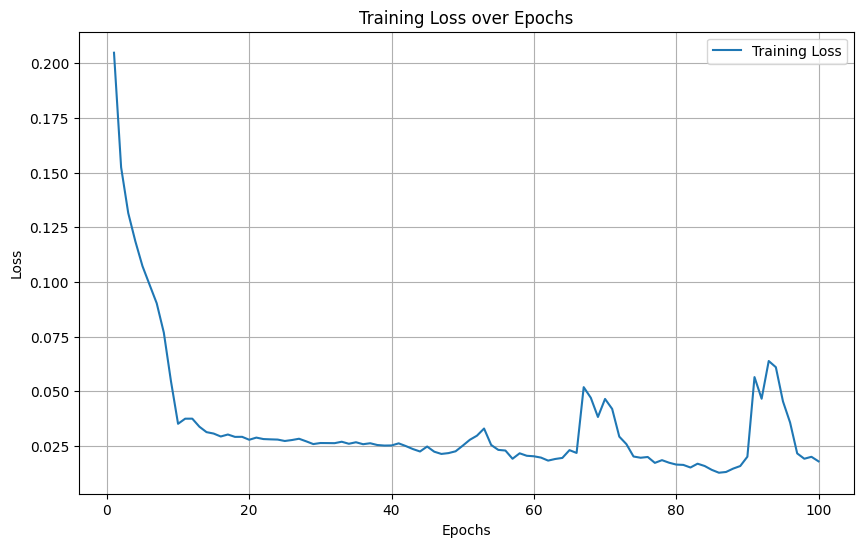

In [11]:
# Train the model
num_epochs = 100
train_losses = train_model(model, train_loader, criterion, optimizer, num_epochs)

# Plot training loss
plt.figure(figsize=(10, 6))
plt.plot(range(1, num_epochs + 1), train_losses, label='Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss over Epochs')
plt.legend()
plt.grid(True)
plt.show()

In [12]:
def evaluate_model(model, test_loader, criterion):
    model.eval()
    test_loss = 0.0
    predictions = []
    actuals = []
    
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            # Reshape input
            X_batch = X_batch.view(X_batch.shape[0], X_batch.shape[1], 1)
            y_batch = y_batch.view(y_batch.shape[0], 1)
            
            # Forward pass
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            test_loss += loss.item()
            
            # Store predictions and actuals
            predictions.extend(outputs.cpu().numpy())
            actuals.extend(y_batch.cpu().numpy())
    
    avg_test_loss = test_loss / len(test_loader)
    print(f'Test Loss: {avg_test_loss:.6f}')
    
    return np.array(predictions), np.array(actuals)

Test Loss: 0.076133


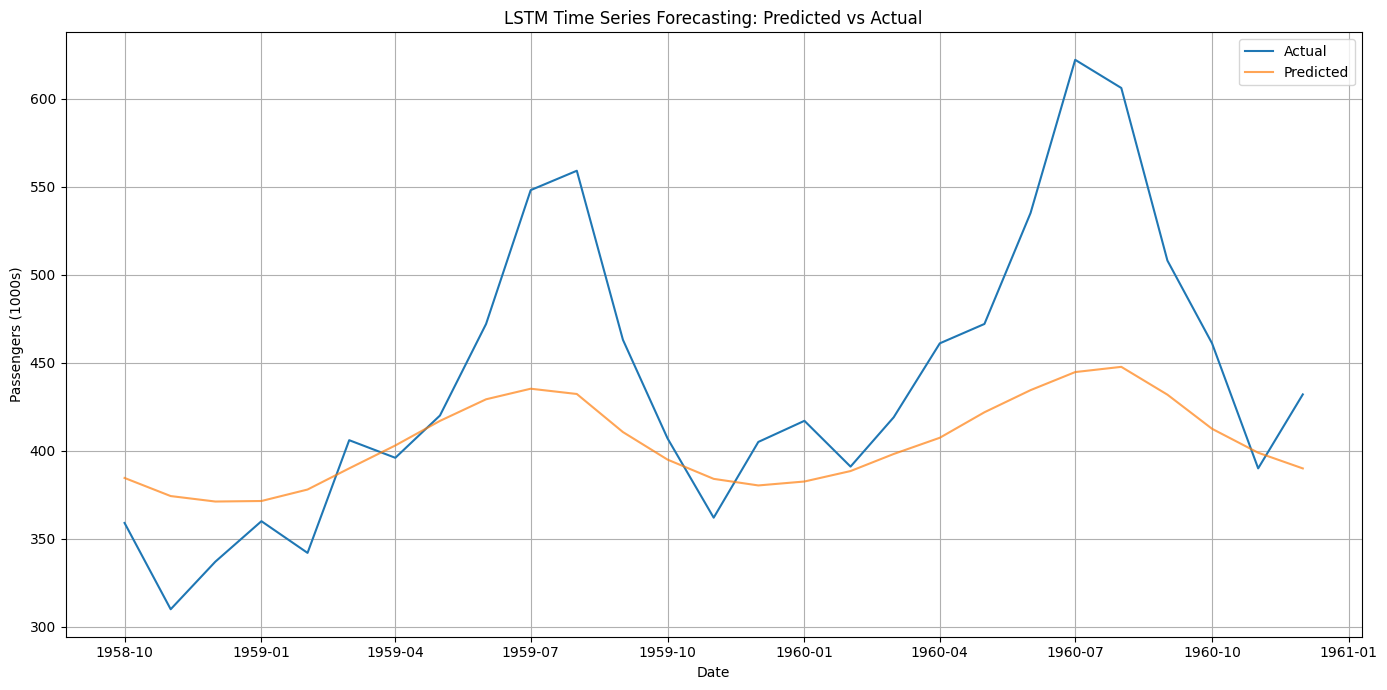

In [13]:
model.eval()
predictions, actuals = evaluate_model(model, test_loader, criterion)

# Inverse transform the scaled values
predictions_transformed = scaler.inverse_transform(predictions)
actuals_transformed = scaler.inverse_transform(actuals)

# Visualize predictions vs actual values
plt.figure(figsize=(14, 7))
plt.plot(df.index[-len(actuals):], actuals_transformed, label='Actual')
plt.plot(df.index[-len(predictions):], predictions_transformed, label='Predicted', alpha=0.7)
plt.title('LSTM Time Series Forecasting: Predicted vs Actual')
plt.xlabel('Date')
plt.ylabel('Passengers (1000s)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [14]:
mse = np.mean((predictions_transformed - actuals_transformed) ** 2)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(predictions_transformed - actuals_transformed))
mape = np.mean(np.abs((actuals_transformed - predictions_transformed) / actuals_transformed)) * 100

print(f'Mean Squared Error: {mse:.4f}')
print(f'Root Mean Squared Error: {rmse:.4f}')
print(f'Mean Absolute Error: {mae:.4f}')
print(f'Mean Absolute Percentage Error: {mape:.4f}%')

Mean Squared Error: 4664.5742
Root Mean Squared Error: 68.2977
Mean Absolute Error: 50.5330
Mean Absolute Percentage Error: 10.5188%


In [15]:
# Function to make future predictions
def predict_future(model, last_sequence, n_steps, scaler):
    model.eval()
    future_predictions = []
    current_sequence = last_sequence.clone()
    
    for _ in range(n_steps):
        # Reshape for model input
        with torch.no_grad():
            current_input = current_sequence.view(1, seq_length, 1)
            prediction = model(current_input)
        
        # Add the prediction to the list
        future_predictions.append(prediction.item())
        
        # Update sequence for next prediction
        current_sequence = torch.cat((current_sequence[1:], prediction.view(1, 1)), dim=0)
    
    # Inverse transform
    future_predictions = np.array(future_predictions).reshape(-1, 1)
    future_predictions_transformed = scaler.inverse_transform(future_predictions)
    
    return future_predictions_transformed

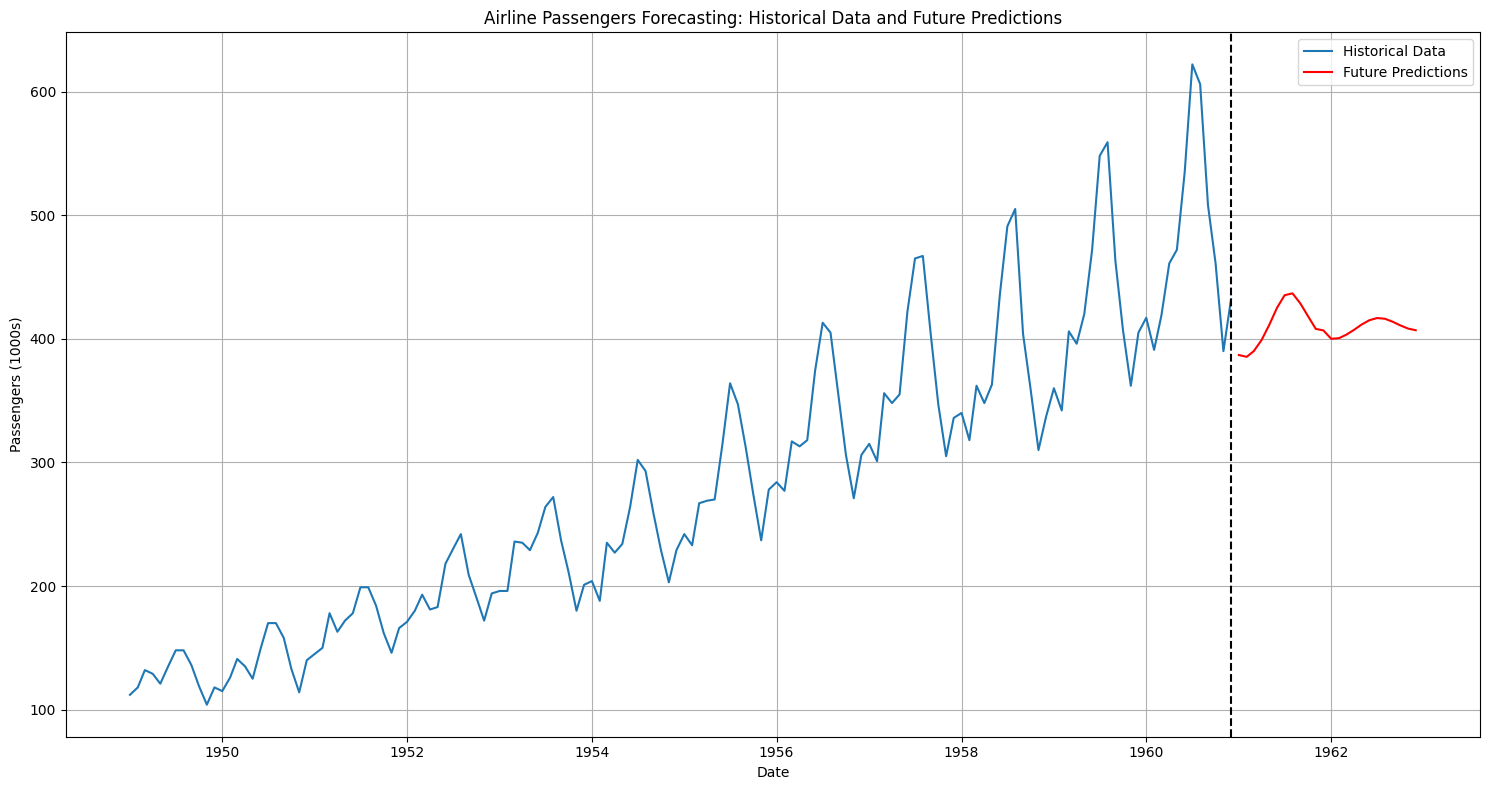

In [16]:
# Get the last sequence from the dataset
last_sequence = torch.FloatTensor(df_scaled[-seq_length:].reshape(seq_length, 1))

# Predict 24 months (2 years) into the future
n_future = 24
future_predictions = predict_future(model, last_sequence, n_future, scaler)

# Create future dates
last_date = df.index[-1]
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=n_future, freq='MS')

# Plot historical data and future predictions
plt.figure(figsize=(15, 8))
plt.plot(df.index, df['Passengers'], label='Historical Data')
plt.plot(future_dates, future_predictions, label='Future Predictions', color='red')
plt.title('Airline Passengers Forecasting: Historical Data and Future Predictions')
plt.xlabel('Date')
plt.ylabel('Passengers (1000s)')
plt.axvline(x=last_date, color='k', linestyle='--')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [17]:
print("Future predictions for the next 24 months:")
for i, (date, prediction) in enumerate(zip(future_dates, future_predictions)):
    print(f"{date.strftime('%Y-%m')}: {prediction[0]:.2f} passengers (thousands)")

Future predictions for the next 24 months:
1961-01: 386.85 passengers (thousands)
1961-02: 385.41 passengers (thousands)
1961-03: 390.02 passengers (thousands)
1961-04: 399.05 passengers (thousands)
1961-05: 411.21 passengers (thousands)
1961-06: 425.14 passengers (thousands)
1961-07: 435.27 passengers (thousands)
1961-08: 436.75 passengers (thousands)
1961-09: 428.59 passengers (thousands)
1961-10: 418.40 passengers (thousands)
1961-11: 407.98 passengers (thousands)
1961-12: 406.80 passengers (thousands)
1962-01: 399.99 passengers (thousands)
1962-02: 400.52 passengers (thousands)
1962-03: 403.22 passengers (thousands)
1962-04: 407.21 passengers (thousands)
1962-05: 411.50 passengers (thousands)
1962-06: 415.04 passengers (thousands)
1962-07: 416.77 passengers (thousands)
1962-08: 416.22 passengers (thousands)
1962-09: 413.80 passengers (thousands)
1962-10: 410.83 passengers (thousands)
1962-11: 408.26 passengers (thousands)
1962-12: 406.92 passengers (thousands)
